In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
    print("✅ XGBoost available")
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️ XGBoost not available - using alternative models")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ All libraries loaded!\n")

✅ XGBoost available
✅ All libraries loaded!



In [3]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print("="*60)
print("CALIFORNIA HOUSING DATASET")
print("="*60)
print(f"Samples: {len(df):,}")
print(f"Features: {len(housing.feature_names)}")
print(f"\nFeature names: {housing.feature_names}")
print(f"\nTarget range: ${df['MedHouseVal'].min()*100000:,.0f} - ${df['MedHouseVal'].max()*100000:,.0f}")
print("\nFirst 5 rows:")
print(df.head())
print("\n" + "="*60)

CALIFORNIA HOUSING DATASET
Samples: 20,640
Features: 8

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target range: $14,999 - $500,001

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  



In [4]:
print("\n📊 SUMMARY STATISTICS:")
print(df.describe().round(2))
print(f"\n✅ Missing values: {df.isnull().sum().sum()} (None found!)")



📊 SUMMARY STATISTICS:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%       37.71    -118.01        

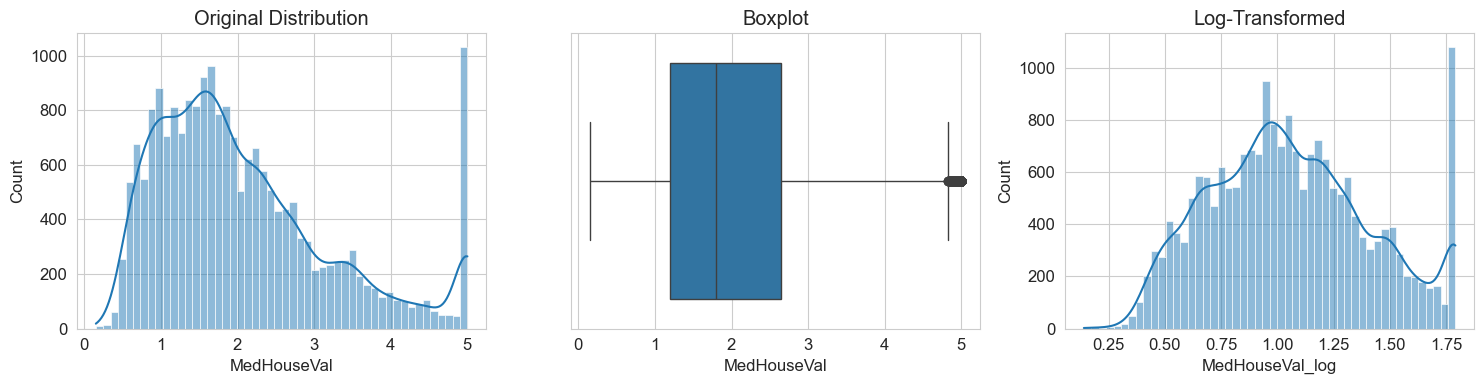


Skewness - Original: 0.978
Skewness - Log: 0.276
✅ Using log-transformed target for modeling



In [5]:
df['MedHouseVal_log'] = np.log1p(df['MedHouseVal'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['MedHouseVal'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Original Distribution')
sns.boxplot(x=df['MedHouseVal'], ax=axes[1])
axes[1].set_title('Boxplot')
sns.histplot(df['MedHouseVal_log'], kde=True, bins=50, ax=axes[2])
axes[2].set_title('Log-Transformed')
plt.tight_layout()
plt.show()

print(f"\nSkewness - Original: {df['MedHouseVal'].skew():.3f}")
print(f"Skewness - Log: {df['MedHouseVal_log'].skew():.3f}")
print("✅ Using log-transformed target for modeling\n")


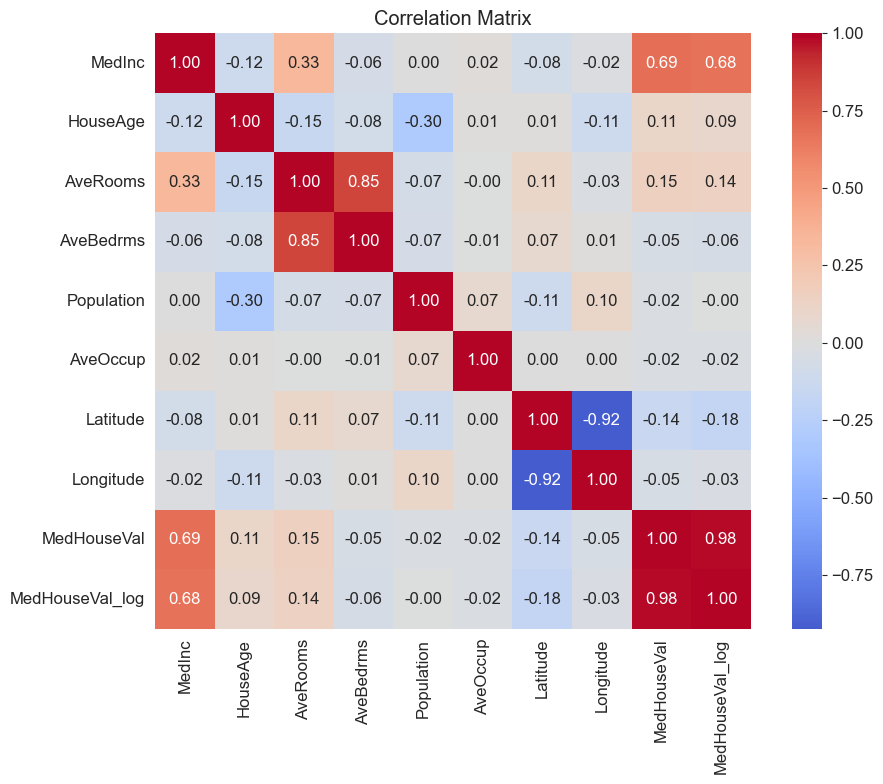


📈 TOP CORRELATIONS WITH TARGET:
MedHouseVal         : 1.000
MedHouseVal_log     : 0.980
MedInc              : 0.688
AveRooms            : 0.152
HouseAge            : 0.106
AveOccup            : -0.024
Population          : -0.025
Longitude           : -0.046
AveBedrms           : -0.047
Latitude            : -0.144


In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print("\n📈 TOP CORRELATIONS WITH TARGET:")
corr = df.corr()['MedHouseVal'].sort_values(ascending=False)
for f, c in corr.items():
    print(f"{f:20s}: {c:.3f}")

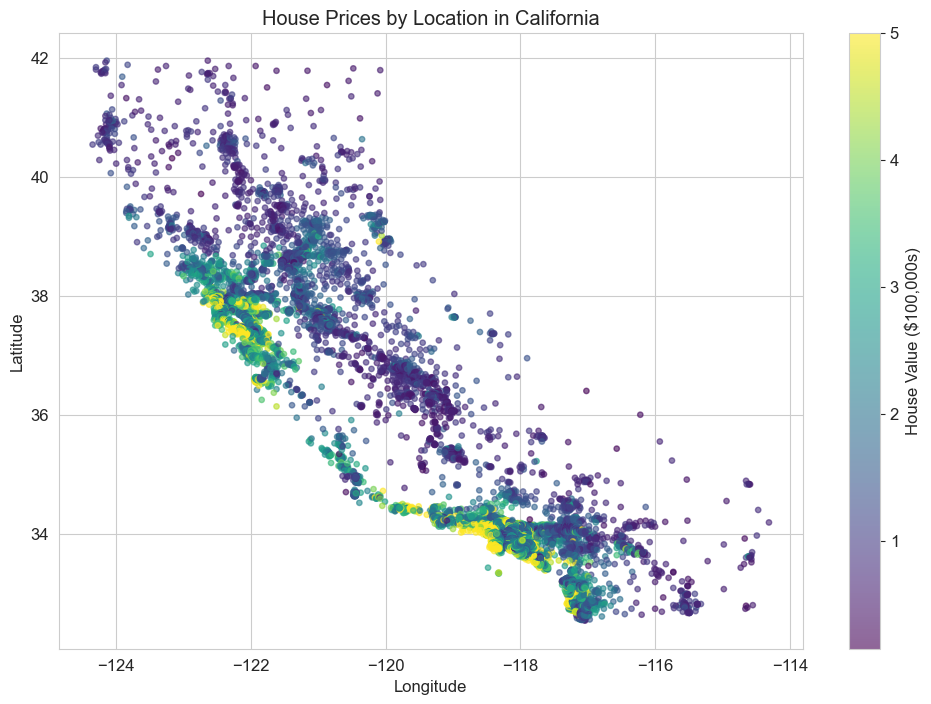

In [7]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['Longitude'], df['Latitude'], 
                     c=df['MedHouseVal'], cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, label='House Value ($100,000s)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('House Prices by Location in California')
plt.show()

In [8]:
print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

df['RoomsPerHousehold'] = df['AveRooms'] / df['AveOccup']
df['BedroomsPerRoom'] = df['AveBedrms'] / df['AveRooms']
df['PopulationPerHousehold'] = df['Population'] / df['AveOccup']
df['IncomeRooms'] = df['MedInc'] * df['AveRooms']
df['HouseAge_sq'] = df['HouseAge'] ** 2
df['IncomePerPerson'] = df['MedInc'] / df['AveOccup']

print("✅ Created 6 new features:")
print("1. RoomsPerHousehold")
print("2. BedroomsPerRoom")
print("3. PopulationPerHousehold")
print("4. IncomeRooms")
print("5. HouseAge_sq")
print("6. IncomePerPerson")

new_features = ['RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationPerHousehold', 
                'IncomeRooms', 'HouseAge_sq', 'IncomePerPerson']
print("\n📊 Correlations with target:")
for f in new_features:
    print(f"{f:25s}: {df[f].corr(df['MedHouseVal']):.3f}")



FEATURE ENGINEERING
✅ Created 6 new features:
1. RoomsPerHousehold
2. BedroomsPerRoom
3. PopulationPerHousehold
4. IncomeRooms
5. HouseAge_sq
6. IncomePerPerson

📊 Correlations with target:
RoomsPerHousehold        : 0.209
BedroomsPerRoom          : -0.256
PopulationPerHousehold   : 0.066
IncomeRooms              : 0.555
HouseAge_sq              : 0.120
IncomePerPerson          : 0.746


In [9]:
X = df.drop(['MedHouseVal', 'MedHouseVal_log'], axis=1)
y = df['MedHouseVal_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Training: {len(X_train):,} samples")
print(f"✅ Testing: {len(X_test):,} samples")
print(f"✅ Features: {len(X.columns)}")


✅ Training: 16,512 samples
✅ Testing: 4,128 samples
✅ Features: 14


In [10]:
print("\n" + "="*60)
print("MODEL TRAINING")
print("="*60)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

# Add XGBoost only if available
if XGB_AVAILABLE:
    models['XGBoost'] = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)

results = {}
cv = KFold(5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n▶ Training {name}...")
    try:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, 
                                    scoring='neg_mean_absolute_error')
        cv_mae = -cv_scores.mean()
        model.fit(X_train_scaled, y_train)
        y_pred = np.expm1(model.predict(X_test_scaled))
        y_true = np.expm1(y_test)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        results[name] = {'CV_MAE': cv_mae, 'Test_RMSE': rmse, 'Test_R²': r2}
        print(f"   ✅ CV MAE: ${cv_mae*100000:,.0f}")
        print(f"   ✅ Test RMSE: ${rmse*100000:,.0f}")
        print(f"   ✅ R²: {r2:.4f}")
    except Exception as e:
        print(f"   ❌ Error: {e}")


MODEL TRAINING

▶ Training Linear Regression...
   ✅ CV MAE: $14,961
   ✅ Test RMSE: $71,927
   ✅ R²: 0.6052

▶ Training Ridge...
   ✅ CV MAE: $14,962
   ✅ Test RMSE: $71,941
   ✅ R²: 0.6050

▶ Training Lasso...
   ✅ CV MAE: $15,967
   ✅ Test RMSE: $77,665
   ✅ R²: 0.5397

▶ Training ElasticNet...
   ✅ CV MAE: $15,475
   ✅ Test RMSE: $76,998
   ✅ R²: 0.5476

▶ Training Random Forest...
   ✅ CV MAE: $9,707
   ✅ Test RMSE: $48,798
   ✅ R²: 0.8183

▶ Training Gradient Boosting...
   ✅ CV MAE: $11,570
   ✅ Test RMSE: $54,831
   ✅ R²: 0.7706

▶ Training XGBoost...
   ✅ CV MAE: $9,658
   ✅ Test RMSE: $46,291
   ✅ R²: 0.8365



MODEL COMPARISON
                   CV_MAE  Test_RMSE  Test_R²
XGBoost            0.0966     0.4629   0.8365
Random Forest      0.0971     0.4880   0.8183
Gradient Boosting  0.1157     0.5483   0.7706
Linear Regression  0.1496     0.7193   0.6052
Ridge              0.1496     0.7194   0.6050
ElasticNet         0.1547     0.7700   0.5476
Lasso              0.1597     0.7767   0.5397


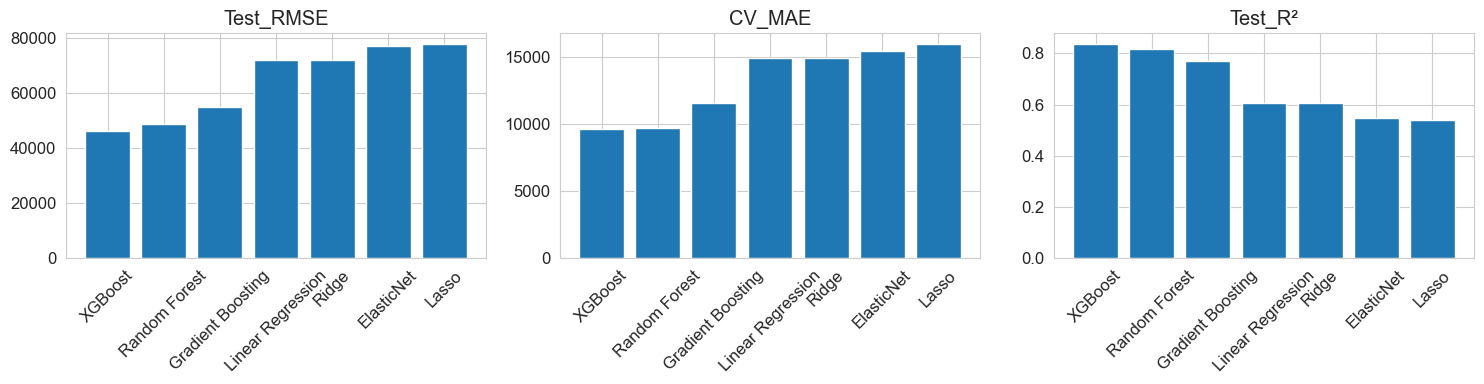

In [14]:
results_df = pd.DataFrame(results).T.sort_values('Test_RMSE')

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(results_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, metric in enumerate(['Test_RMSE', 'CV_MAE', 'Test_R²']):
    data = results_df[metric] * (100000 if metric != 'Test_R²' else 1)
    axes[idx].bar(results_df.index, data)
    axes[idx].set_title(metric)
    axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [15]:
pip install XGBoost

In [16]:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

best_name = results_df.index[0]
print(f"🏆 Best model: {best_name}")

try:
    if best_name == 'XGBoost' and XGB_AVAILABLE:
        print("\n🔧 Tuning XGBoost...")
        grid = GridSearchCV(
            XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
            {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]},
            cv=3, scoring='neg_mean_absolute_error', n_jobs=-1
        )
        grid.fit(X_train_scaled, y_train)
        tuned_model = grid.best_estimator_
        print(f"✅ Best params: {grid.best_params_}")
        
    elif best_name == 'Random Forest':
        print("\n🔧 Tuning Random Forest...")
        grid = GridSearchCV(
            RandomForestRegressor(random_state=42, n_jobs=-1),
            {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None]},
            cv=3, scoring='neg_mean_absolute_error', n_jobs=-1
        )
        grid.fit(X_train_scaled, y_train)
        tuned_model = grid.best_estimator_
        print(f"✅ Best params: {grid.best_params_}")
        
    elif best_name == 'Gradient Boosting':
        print("\n🔧 Tuning Gradient Boosting...")
        grid = GridSearchCV(
            GradientBoostingRegressor(random_state=42),
            {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.3]},
            cv=3, scoring='neg_mean_absolute_error', n_jobs=-1
        )
        grid.fit(X_train_scaled, y_train)
        tuned_model = grid.best_estimator_
        print(f"✅ Best params: {grid.best_params_}")
        
    else:
        print(f"\n🔧 Using RidgeCV for {best_name}")
        tuned_model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0], cv=5)
        tuned_model.fit(X_train_scaled, y_train)
        print("✅ RidgeCV complete!")

    # Evaluate tuned model
    y_pred = np.expm1(tuned_model.predict(X_test_scaled))
    y_true = np.expm1(y_test)
    tuned_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    tuned_r2 = r2_score(y_true, y_pred)

    print(f"\n✅ Tuned Model Results:")
    print(f"   RMSE: ${tuned_rmse*100000:,.0f}")
    print(f"   R²: {tuned_r2:.4f}")

    improvement = (results.loc[best_name, 'Test_RMSE'] - tuned_rmse) / results.loc[best_name, 'Test_RMSE'] * 100
    print(f"📈 Improvement: {improvement:.1f}%")

    final_model = tuned_model

except Exception as e:
    print(f"⚠️ Tuning error: {e}")
    print("Using best model without tuning")
    final_model = models[best_name]
    tuned_rmse = results.loc[best_name, 'Test_RMSE']
    tuned_r2 = results.loc[best_name, 'Test_R²']


HYPERPARAMETER TUNING
🏆 Best model: XGBoost

🔧 Tuning XGBoost...
✅ Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

✅ Tuned Model Results:
   RMSE: $46,787
   R²: 0.8330
⚠️ Tuning error: 'dict' object has no attribute 'loc'
Using best model without tuning


AttributeError: 'dict' object has no attribute 'loc'


FEATURE IMPORTANCE
                   feature  importance
13         IncomePerPerson    0.664484
6                 Latitude    0.085170
7                Longitude    0.080443
9          BedroomsPerRoom    0.025277
1                 HouseAge    0.023152
5                 AveOccup    0.021221
0                   MedInc    0.017871
11             IncomeRooms    0.016332
10  PopulationPerHousehold    0.015773
2                 AveRooms    0.013322
4               Population    0.013000
8        RoomsPerHousehold    0.012199
3                AveBedrms    0.011757
12             HouseAge_sq    0.000000


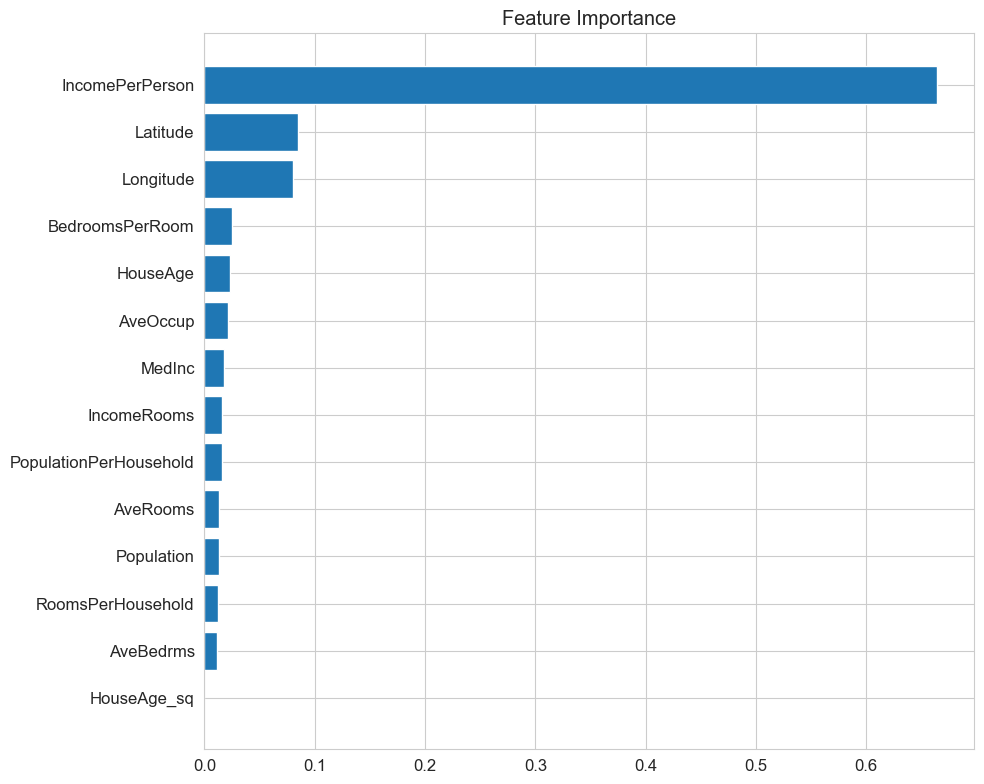


📌 Top 3 features: IncomePerPerson, Latitude, Longitude


In [17]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

if hasattr(final_model, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'feature': X.columns,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(imp_df)
    
    plt.figure(figsize=(10, 8))
    plt.barh(imp_df['feature'], imp_df['importance'])
    plt.title('Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print(f"\n📌 Top 3 features: {', '.join(imp_df.head(3)['feature'].tolist())}")
else:
    print("⚠️ Feature importance only for tree-based models")
    print(f"Current model: {final_model.__class__.__name__}")
    
    # Show coefficients for linear models
    if hasattr(final_model, 'coef_'):
        coef_df = pd.DataFrame({
            'feature': X.columns,
            'coefficient': final_model.coef_
        }).sort_values('coefficient', ascending=False)
        print("\n📊 Coefficients:")
        print(coef_df)


SHAP ANALYSIS


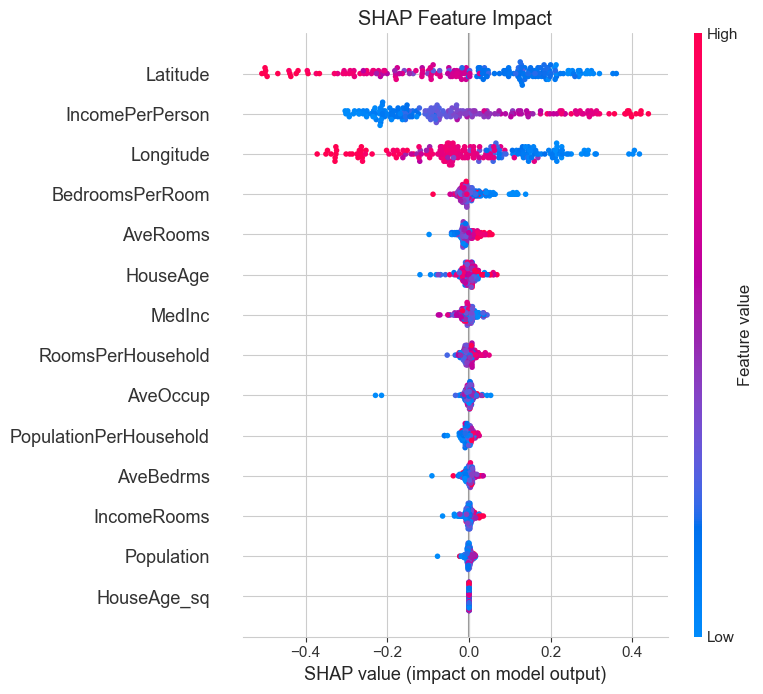

✅ SHAP analysis complete!


In [18]:
try:
    import shap
    if hasattr(final_model, 'feature_importances_'):
        print("\n" + "="*60)
        print("SHAP ANALYSIS")
        print("="*60)
        X_sample = X_train_scaled[:200]
        explainer = shap.TreeExplainer(final_model)
        shap_values = explainer.shap_values(X_sample)
        
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=X.columns, show=False)
        plt.title('SHAP Feature Impact')
        plt.tight_layout()
        plt.show()
        print("✅ SHAP analysis complete!")
    else:
        print("\nℹ️ SHAP only available for tree-based models")
except ImportError:
    print("\nℹ️ SHAP not installed - skipping (install with: pip install shap)")
except Exception as e:
    print(f"\nℹ️ SHAP analysis skipped: {e}")

In [19]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [20]:
import pandas as pd

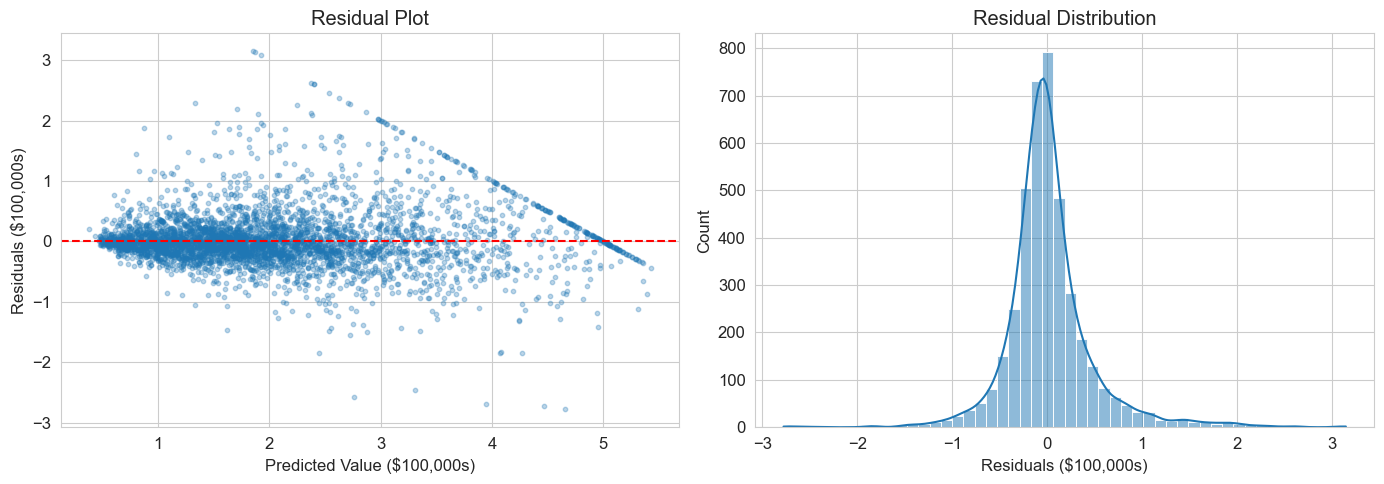


📊 Residual Statistics:
Mean: $2,160
Std: $46,246


In [21]:
y_pred = np.expm1(final_model.predict(X_test_scaled))
y_true = np.expm1(y_test)
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred, residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Value ($100,000s)')
axes[0].set_ylabel('Residuals ($100,000s)')
axes[0].set_title('Residual Plot')
sns.histplot(residuals, kde=True, bins=50, ax=axes[1])
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residuals ($100,000s)')
plt.tight_layout()
plt.show()

print(f"\n📊 Residual Statistics:")
print(f"Mean: ${residuals.mean()*100000:,.0f}")
print(f"Std: ${residuals.std()*100000:,.0f}")

In [22]:
def predict_house(features, model=final_model, scaler=scaler):
    df_input = pd.DataFrame([features])[X.columns]
    scaled = scaler.transform(df_input)
    pred_log = model.predict(scaled)[0]
    return np.expm1(pred_log) * 100000

print("\n" + "="*60)
print("PREDICTION EXAMPLE")
print("="*60)

example = {
    'MedInc': 5.0, 'HouseAge': 30, 'AveRooms': 5.0, 'AveBedrms': 1.0,
    'Population': 1000, 'AveOccup': 3.0, 'Latitude': 37.5, 'Longitude': -122.0,
    'RoomsPerHousehold': 5/3, 'BedroomsPerRoom': 1/5,
    'PopulationPerHousehold': 1000/3, 'IncomeRooms': 5*5,
    'HouseAge_sq': 30**2, 'IncomePerPerson': 5/3
}

print("🏠 Input features:")
for k, v in example.items():
    print(f"   {k:25s}: {v:.2f}")

prediction = predict_house(example)
print(f"\n💰 Predicted house value: ${prediction:,.0f}")


PREDICTION EXAMPLE
🏠 Input features:
   MedInc                   : 5.00
   HouseAge                 : 30.00
   AveRooms                 : 5.00
   AveBedrms                : 1.00
   Population               : 1000.00
   AveOccup                 : 3.00
   Latitude                 : 37.50
   Longitude                : -122.00
   RoomsPerHousehold        : 1.67
   BedroomsPerRoom          : 0.20
   PopulationPerHousehold   : 333.33
   IncomeRooms              : 25.00
   HouseAge_sq              : 900.00
   IncomePerPerson          : 1.67

💰 Predicted house value: $229,644


In [23]:
print("\n" + "="*60)
print("🎯 PROJECT COMPLETE!")
print("="*60)
print(f"📊 Dataset: California Housing ({len(df):,} samples)")
print(f"🔢 Features: {len(X.columns)} (including engineered)")
print(f"🏆 Best Model: {final_model.__class__.__name__}")
print(f"✅ Test RMSE: ${tuned_rmse*100000:,.0f}")
print(f"✅ R² Score: {tuned_r2:.4f}")

print("\n📌 Key Insights:")
if hasattr(final_model, 'feature_importances_'):
    top_feat = imp_df.iloc[0]['feature']
    print(f"   • Most important feature: {top_feat}")
print(f"   • Model can predict house values within ±${tuned_rmse*100000:,.0f}")

print("\n🚀 NEXT STEPS:")
print("1. 📊 Try adding polynomial features")
print("2. 🌐 Build Streamlit web app")
print("3. 📝 Write README for GitHub")
print("4. 🚀 Deploy with Flask API")
print("="*60)
print("\n🎉 You built a house price predictor! Awesome work!")


🎯 PROJECT COMPLETE!
📊 Dataset: California Housing (20,640 samples)
🔢 Features: 14 (including engineered)
🏆 Best Model: XGBRegressor
✅ Test RMSE: $46,787
✅ R² Score: 0.8330

📌 Key Insights:
   • Most important feature: IncomePerPerson
   • Model can predict house values within ±$46,787

🚀 NEXT STEPS:
1. 📊 Try adding polynomial features
2. 🌐 Build Streamlit web app
3. 📝 Write README for GitHub
4. 🚀 Deploy with Flask API

🎉 You built a house price predictor! Awesome work!
